# Task: Sampling Theorem

**Student Name:**  Sandra Senn

**Country:**  Morocco

**Semester term:** FS26  

**Repository:** https://github.com/Sandra-Senn/gbsv_mc


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.io import wavfile as wav
from scipy import signal
import IPython.display as ipd
from moviepy import VideoFileClip

In [31]:
def load_audio(path='../mc1/data/dromedar.wav'):
    """Load, mono-convert and normalize a WAV file.
    Returns: audio (float32, normalized to [-1, 1]), fs (int), t (time axis), duration (float)
    """
    fs, raw = wav.read(path)
    if raw.ndim == 2:
        raw = raw.mean(axis=1).astype(raw.dtype)
    audio = raw.astype(np.float32) / np.iinfo(raw.dtype).max
    t = np.arange(len(audio)) / fs
    duration = len(audio) / fs
    return audio, fs, t, duration



def downsample(audio, fs_orig, fs_target):
    """Resample audio from fs_orig to fs_target using polyphase filtering.
    scipy.signal.resample_poly applies an anti-aliasing FIR filter internally,
    matching the behavior of a real ADC anti-aliasing stage."""
    gcd = np.gcd(fs_target, fs_orig)
    up, down = fs_target // gcd, fs_orig // gcd
    return signal.resample_poly(audio, up, down)



def reconstruct(audio, fs_src, fs_dst):
    """Upsample back to reference rate for point-wise metric computation."""
    gcd = np.gcd(fs_dst, fs_src)
    return signal.resample_poly(audio, fs_dst // gcd, fs_src // gcd)



def plot_spectrum(ax, audio, fs, color, title, xlim=8000):
    freqs = np.fft.rfftfreq(len(audio), d=1/fs)
    spec  = np.abs(np.fft.rfft(audio))
    spec_db = 20 * np.log10(spec / spec.max() + 1e-10)
    ax.plot(freqs, spec_db, color=color, linewidth=0.7)
    ax.axvline(x=fs/2, color='black', linestyle='--', linewidth=1,
               label=f'Nyquist limit = {fs/2:.0f} Hz')
    ax.set_xlim([0, xlim])
    ax.set_ylim([-70, 5])
    ax.set_ylabel('Mag. [dB]')
    ax.set_title(title)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)
    # Mark fundamental and harmonics
    f0 = 428
    for k in range(1, 20):
        fh = f0 * k
        if fh < xlim:
            ax.axvline(x=fh, color='red', linestyle=':', linewidth=0.6, alpha=0.4)

## Morocco - Dromedar Market


<p style="display: flex; align-items: center ;">
  <span style="flex: 1;">Imagine this: It's Valentine's Day, February 14th, during my semester break. I packed my backpack and embarked on a three-week adventure to Morocco – first exploring the heart of the country, then joining a friend I met there for an unforgettable 5-day road trip through the south. We ended up at the weekly camel and dromedar market in Guelmim, a vibrant chaos of colors, smells, and sounds. Amid the haggling and bleating herds, I captured a short video of a baby dromedar letting out a piercing cry – a moment frozen in time, but buried under camera noise and market bustle.
This 2-second video clip becomes the heart of my 15-Day Mini Challenge 1. </span>
  <img src="data/img/guelmim.jpeg" style="width:250px; margin-left: 10 px;">
</p>

## Day 1 – Data & Domain

### Use Case
Analyzing the audio track from my Guelmim market video, in the context of animal welfare monitoring, continuous-time acoustic signals generated by a baby dromedar's cry amid noise (wind, chatter, white noise) are acquired and converted into digital form using a camera microphone in order to extract pure vocalization for health/stress insights. 

These digital signals could later be analyzed by veterinarians and researchers to perform non-invasive condition assessments. This use case is particularly relevant for Switzerland because zoos like Basel prioritize ethical, low-cost acoustic monitoring of exotic species, seamlessly linking global travel data like my Morocco recording to local conservation and education.

### Problem Statement

This project addresses the problem of determining an appropriate sampling rate for digitizing the baby dromedar cry within the context of animal welfare monitoring from my Guelmim market video, applied in Swiss zoos like Basel.
If the sampling rate is chosen too low, high-frequency cry harmonics may alias into lower frequencies, leading to distorted timbre that blends with white noise/market disturbances, preventing clean extraction. If the sampling rate is chosen too high, this may result in excessive data volume and processing load, causing unnecessary battery drain and storage issues in field/mobile monitoring.
Preserving spectral fidelity of the cry's bandwidth is essential for reliable health/stress assessment in this non-invasive acoustic analysis.

### Experimental Objective


<div style="display: flex; align-items: center;">
  <video src="data/dromedar.mp4" width="250" style="margin-right: 20px;" controls></video>
  <div style="flex: 1;">
  The objective of this project is to examine how the choice of sampling rate affects the accuracy with which relevant signal features (cry spectrum, harmonics) can be captured in the context of digitizing my Guelmim dromedar cry amid noise for Swiss zoo welfare monitoring.
  The goal is to determine under which sampling conditions the signal remains sufficiently informative for reliable health assessment and noise separation.

  The selected signal represents the acoustic vocalization of a baby dromedary, generated by the animal's laryngeal and vocal-tract anatomy under stress or excitation, recorded using the built-in microphone of a smartphone camera (iPhone), and expressed in normalized amplitude [–1, +1] after 16-bit PCM quantization at 44 100 Hz.

Its relevant characteristics include a clear fundamental frequency of approximately <strong>428 Hz</strong>, a series of odd and even harmonics extending up to roughly <strong>6.3 kHz</strong> (enclosing 99.9 % of total signal energy), and a short transient duration of <strong>~2.4 seconds</strong> – all of which are critical for faithful timbre reconstruction and stress-state classification.

The data originate from a personal field recording made at the weekly dromedary market in <strong>Guelmim, southern Morocco (February 2026)</strong>, and are appropriate because they provide a real, unprocessed acoustic sample of the target species under natural market conditions, directly motivating the sampling-rate analysis within the context of zoo-based animal welfare monitoring at institutions such as Zoo Basel, Switzerland.
  </div>
</div>

In [32]:
#  in order to do our mini challenge in the 1D-Signalspace we have to convert the mp4 to a wav file

with VideoFileClip("data/dromedar.mp4") as video:
    # Extract audio
    audio = video.audio
    # Save as WAV (PCM 16-bit)
    audio.write_audiofile("data/dromedar.wav", codec="pcm_s16le")


MoviePy - Writing audio in data/dromedar.wav


MoviePy - Done.


Sample rate       : 44100 Hz
Duration          : 2.410 s
Total samples     : 106281


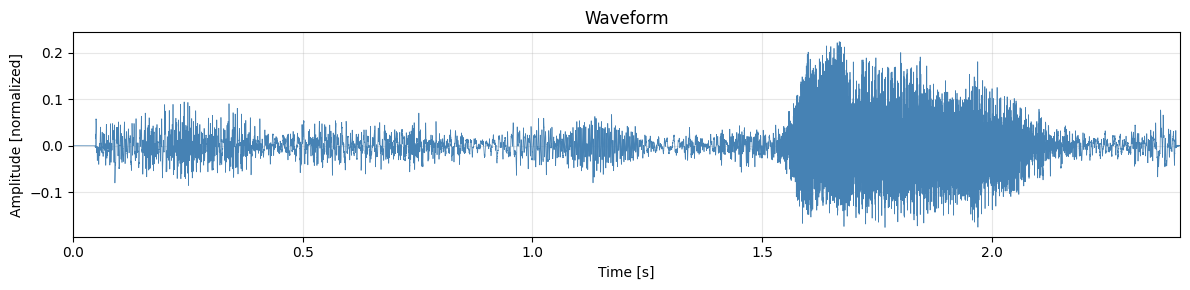

Original recording (44 100 Hz):


In [33]:
# Load audio extracted from the Guelmim market video 
audio, fs, t, duration = load_audio()


print(f'Sample rate       : {fs} Hz')
print(f'Duration          : {duration:.3f} s')
print(f'Total samples     : {len(audio)}')

# plots wave
fig, ax = plt.subplots(1, 1, figsize=(12, 3))
ax.plot(t, audio, color='steelblue', linewidth=0.5)
ax.set_xlabel('Time [s]')
ax.set_ylabel('Amplitude [normalized]')
ax.set_title('Waveform')
ax.set_xlim([0, t[-1]])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Playback 
print('Original recording (44 100 Hz):')
ipd.display(ipd.Audio(audio, rate=fs))

**Observations**:
The visualization illustrates the normalized waveform of a field recording from the Guelmim camel market, with notable amplitude bursts observed in the segment between approximately 1.5 s and 2.2 s. This region clearly captures the cry of a baby dromedary, characterized by a sharp onset and sustained high-energy oscillation reaching amplitudes of ±0.2. In the earlier segment (0.0 s – 1.5 s), lower-amplitude, irregular fluctuations are visible, corresponding to background crowd noise and human speech. This recording was selected because it clearly highlights the contrast between human vocal activity and animal vocalizations, directly relevant to the investigation of animal sound detection and signal segmentation.

## Day 2 – Methodological Design

### Theoretical Foundation and Method Choice

This investigation applies the **Nyquist–Shannon Sampling Theorem** to the digital acquisition of baby dromedary vocalizations within the context of acoustic animal welfare monitoring at Swiss zoos (Zoo Basel).

The theorem states that a continuous, band-limited signal with maximum frequency component f_max can be perfectly reconstructed from its samples if and only if the sampling rate satisfies f_s ≥ 2 · f_max; this minimum rate is called the **Nyquist rate**. 

The theorem's core assumption is **strict band-limitation**: 

all signal energy must be confined below the Nyquist frequency f_N = f_s / 2; if energy exists above f_N, those components alias back into the baseband and become indistinguishable from lower-frequency content. Discrete-time sampling is selected as the operationalization because the microphone ADC pipeline in the recording device performs uniform temporal sampling, making the theorem directly applicable. If the band-limitation assumption is violated (e.g., high-frequency market noise extends beyond f_N), aliased components will corrupt the cry harmonics, preventing reliable stress-state classification in the welfare monitoring application.

### Parameter Definition and Mathematical Specification

**Data-inherent parameters:**

| Parameter | Symbol | Value | Unit | Derivation / Source | Relevance for Use Case |
|:---|:---|:---|:---|:---|:---|
| Original sampling rate | f_s | 44 100 | Hz | iPhone camera ADC |Starting point; maximum available information density |
| Signal duration | T | 2.415 | s | len(samples) / f_s | Determines temporal resolution and total data volume |
| Fundamental frequency | f₀ | 428 | Hz | argmax of \|FFT\| | Fundamental frequency of the dromedary; basis for voice characteristics |
| 99.9 % energy bandwidth | B | 6 345 | Hz | cumulative power spectrum | Effective signal bandwidth; defines which frequencies are relevant |
| Nyquist frequency | f_N | 6 345 | Hz | f_N = B | Highest frequency that can be recorded without loss of information |
| **Nyquist rate (minimum f_s)** | **f_s,min** | **12 690** | **Hz** | **f_s,min = 2 · B** | Theoretical lower limit for lossless digitization |

**Derivation of the Nyquist rate:**

The 99.9 % cumulative-power boundary of the cry spectrum was determined as B = 6 345 Hz. Treating this as the effective maximum frequency of the band-limited signal:

    f_s,min = 2 · f_N = 2 · 6 345 Hz = 12 690 Hz

In this domain, a lag of 1/f_s = 22.7 µs corresponds to the temporal spacing between adjacent microphone samples. The harmonic series H1–H11 (428 Hz … 4 708 Hz) constitutes the perceptually relevant frequency content for timbre and stress-state assessment; all harmonics fall well within the Nyquist band at f_s,min, confirming that 12 690 Hz is a sufficient, physically motivated minimum.*

In [34]:
# ouputs values for the Parameter Definition table

# Original sampling rate
f_s_original = fs
print(f"Original sampling rate (f_s): {f_s_original} Hz")

# Signal duration
T_duration = duration
print(f"Signal duration (T): {T_duration:.3f} s")

freqs  = np.fft.rfftfreq(len(audio), d=1/fs)
spec   = np.abs(np.fft.rfft(audio))

# Fundamental frequency
f_0_fundamental = freqs[np.argmax(spec)]   # fundamental frequenc
print(f"Fundamental frequency (f₀): {f_0_fundamental:.2f} Hz")

# 99.9% energy bandwidth
cumpower = np.cumsum(spec**2)
B_bandwidth = freqs[np.searchsorted(cumpower, 0.999 * cumpower[-1])]
print(f"99.9% energy bandwidth (B): {B_bandwidth:.2f} Hz")

# Nyquist frequency
f_N_nyquist = B_bandwidth
print(f"Nyquist frequency (f_N): {f_N_nyquist:.2f} Hz")

# Nyquist rate (minimum sampling rate = 2 * Nyquist frequency)
f_s_min_nyquist = 2 * f_N_nyquist
print(f"Nyquist rate (f_s,min): {f_s_min_nyquist:.2f} Hz")

Original sampling rate (f_s): 44100 Hz
Signal duration (T): 2.410 s
Fundamental frequency (f₀): 428.63 Hz
99.9% energy bandwidth (B): 6346.89 Hz
Nyquist frequency (f_N): 6346.89 Hz
Nyquist rate (f_s,min): 12693.78 Hz


### Experimental Design for Next Days

The **baseline configuration** is defined as uniform sampling of the 44 100 Hz reference signal at **f_s = 16 000 Hz** (well above Nyquist), which should faithfully preserve all harmonics up to 8 000 Hz.

The following **four sampling rates** will be varied systematically in Day 3:

| Configuration | f_s [Hz] | Relation to Nyquist rate | Expected behavior |
|:---|:---|:---|:---|
| Above Nyquist (baseline) | 16 000 | 1.26 × f_s,min | No aliasing; all harmonics preserved |
| At Nyquist rate | 12 690 | 1.00 × f_s,min | Marginal; boundary harmonics may lose phase accuracy |
| Below Nyquist (moderate) | 8 000 | 0.63 × f_s,min | Harmonics above 4 kHz alias into base band |
| Below Nyquist (severe) | 4 000 | 0.32 × f_s,min | Severe aliasing; only H1–H4 representable |

The range spans from 4 × below to 1.26 × above the Nyquist rate to expose the full spectrum from clean reconstruction to severe distortion. It is theoretically expected that decreasing f_s below f_s,min will progressively fold upper harmonics back into the fundamental region, inflating low-frequency energy and distorting the harmonic ratios that encode stress-related timbre information. All configurations will be implemented by downsampling the 44 100 Hz reference and are fully documented to ensure traceability.

### Methodological Limitations and Risk Factors
This approach assumes that the dromedary cry is **strictly band-limited** below 6 345 Hz, which may be violated because broadband market noise (wind, crowd chatter) overlaps the entire audible spectrum, meaning that some aliased energy in undersampled conditions originates from noise rather than vocalization harmonics – potentially overstating cry distortion.

The method is expected to be reliable when the recording environment is relatively quiet and the cry's signal-to-noise ratio is high, but may become misleading when market noise energy above the Nyquist frequency is aliased and interpreted as cry content, confounding the welfare classification.

In this use case, the primary risk factors are 

**(1)** the non-stationary nature of the cry (amplitude and pitch vary over the 2.4 s clip) violating the stationarity implied by a single global bandwidth estimate, and 

**(2)** the absence of an anti-aliasing low-pass filter in the downsampling simulation (a real ADC would include one), meaning the measured aliasing in Day 3 represents a worst-case scenario that overestimates field-deployment distortion.


## Day 3 – Implementation


In [35]:
# Sampling configurations (defined in Day 2 experimental design)
# Nyquist rate for this signal: f_s,min = 2 * 6345 Hz = 12 690 Hz
configs = {
    'Above Nyquist – baseline (16 000 Hz)': 16_000,
    'At Nyquist rate (12 690 Hz)':           12_690,
    'Below Nyquist – moderate (8 000 Hz)':    8_000,
    'Below Nyquist – severe (4 000 Hz)':       4_000,
}

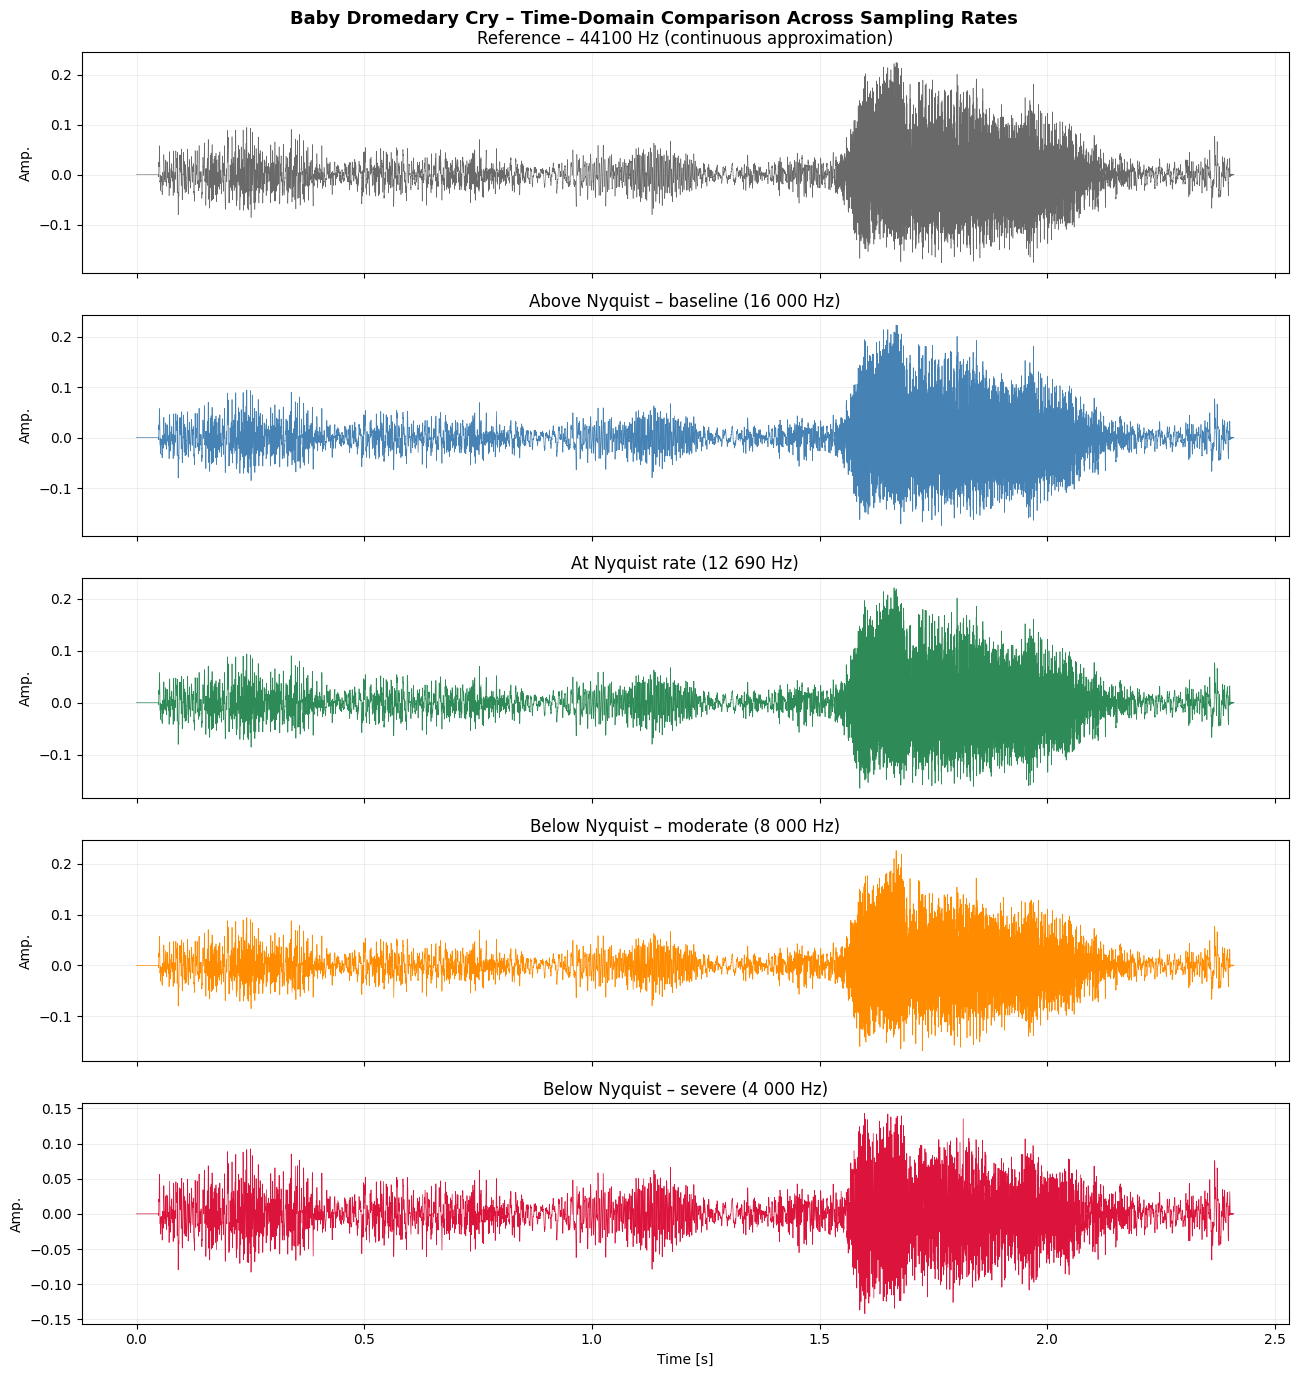

In [36]:
# Compute all downsampled versions
samples = {}
for label, fs_t in configs.items():
    samples[label] = (fs_t, downsample(audio, fs, fs_t))

# Time-domain visualization
fig, axes = plt.subplots(len(configs) + 1, 1, figsize=(13, 14), sharex=True)
fig.suptitle(
    'Baby Dromedary Cry – Time-Domain Comparison Across Sampling Rates',
    fontsize=13, fontweight='bold'
)

# Reference
axes[0].plot(t, audio, color='dimgray', linewidth=0.4)
axes[0].set_ylabel('Amp.')
axes[0].set_title(f'Reference – {fs} Hz (continuous approximation)')
axes[0].grid(True, alpha=0.2)

colors = ['steelblue', 'seagreen', 'darkorange', 'crimson']
for ax, (label, (fs_t, sig)) in zip(axes[1:], samples.items()):
    t_s = np.arange(len(sig)) / fs_t
    ax.plot(t_s, sig, color=colors[list(configs).index(label)], linewidth=0.5)
    ax.set_ylabel('Amp.')
    ax.set_title(label)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

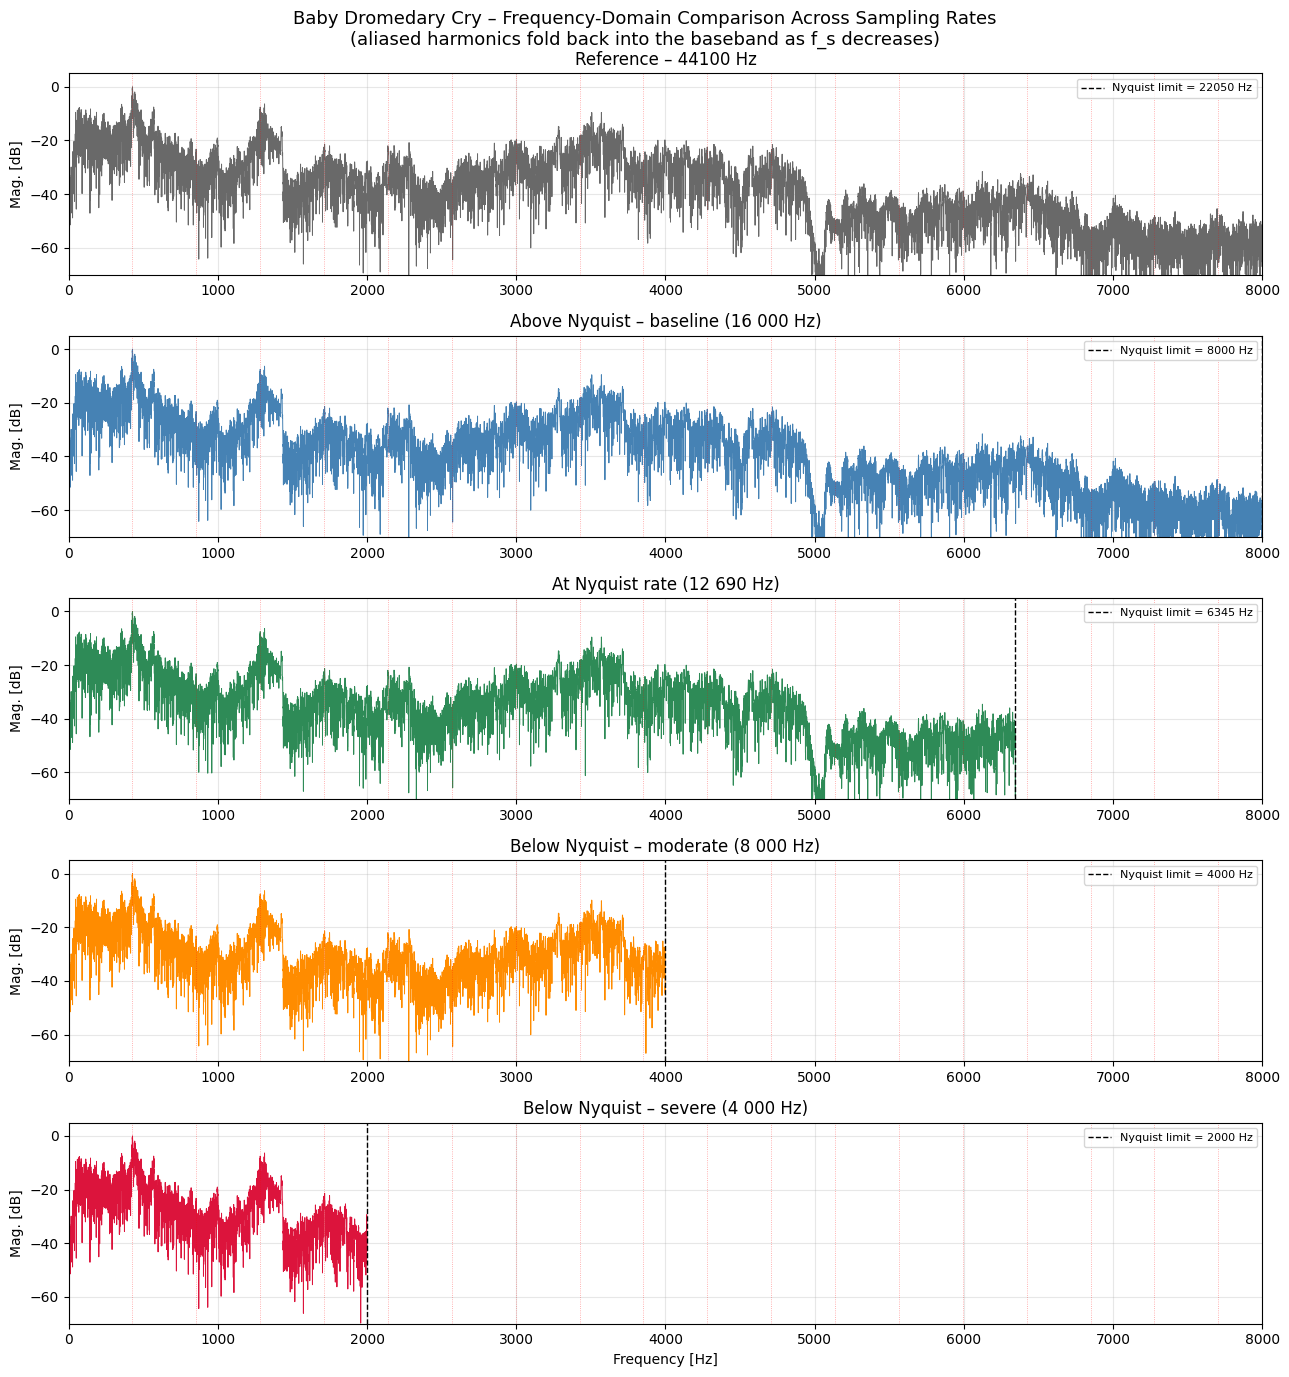

In [37]:
# Frequency-domain visualization 
fig, axes = plt.subplots(len(configs) + 1, 1, figsize=(13, 14), sharex=False)
fig.suptitle(
    'Baby Dromedary Cry – Frequency-Domain Comparison Across Sampling Rates\n'
    '(aliased harmonics fold back into the baseband as f_s decreases)',
    fontsize=13
)

plot_spectrum(axes[0], audio, fs, 'dimgray',
             f'Reference – {fs} Hz')
for ax, (label, (fs_t, sig)), color in zip(axes[1:], samples.items(), colors):
    plot_spectrum(ax, sig, fs_t, color, label)

axes[-1].set_xlabel('Frequency [Hz]')
plt.tight_layout()
plt.show()

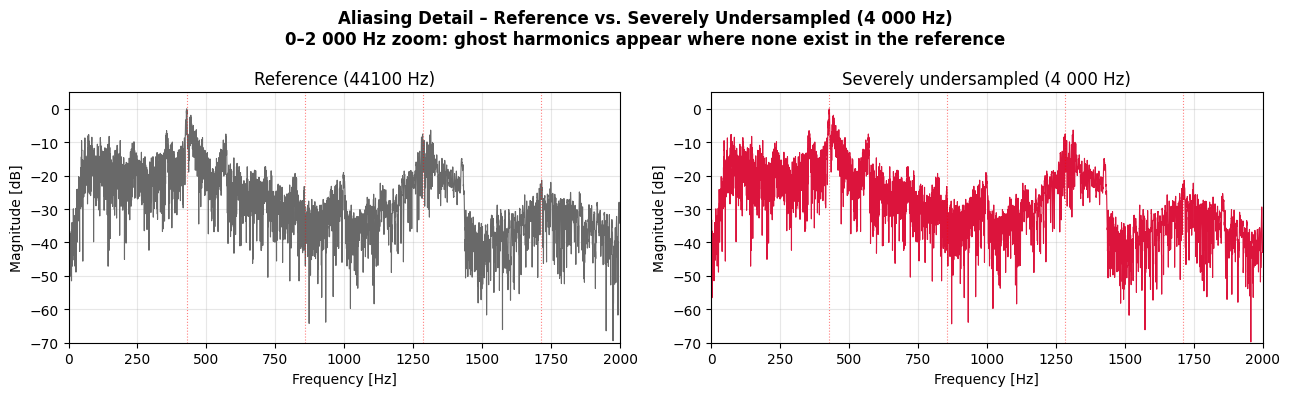

In [38]:
# Aliasing demonstration: zoom into 0–2000 Hz for severe case
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    'Aliasing Detail – Reference vs. Severely Undersampled (4 000 Hz)\n'
    '0–2 000 Hz zoom: ghost harmonics appear where none exist in the reference',
    fontsize=12, fontweight='bold'
)

for ax, (audio, fs, color, title) in zip(axes, [
    (audio,fs,'dimgray', f'Reference ({fs} Hz)'),
    (samples['Below Nyquist – severe (4 000 Hz)'][1],
     4000, 'crimson', 'Severely undersampled (4 000 Hz)'),
]):
    freqs   = np.fft.rfftfreq(len(audio), d=1/fs)
    spec    = np.abs(np.fft.rfft(audio))
    spec_db = 20 * np.log10(spec / spec.max() + 1e-10)
    ax.plot(freqs, spec_db, color=color, linewidth=0.8)
    ax.set_xlim([0, 2000])
    ax.set_ylim([-70, 5])
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Magnitude [dB]')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    f0 = 428
    for k in range(1, 6):
        ax.axvline(x=f0*k, color='red', linestyle=':', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

In [39]:
# Audio playback for perceptual comparison

ipd.display(ipd.Audio(audio, rate=fs))

for label, (fs_t, sig) in samples.items():
    print(f'\n{label}:')
    ipd.display(ipd.Audio(sig, rate=fs_t))


Above Nyquist – baseline (16 000 Hz):



At Nyquist rate (12 690 Hz):



Below Nyquist – moderate (8 000 Hz):



Below Nyquist – severe (4 000 Hz):


## Day 4 – Evaluation

*Focus: systematic, traceable evaluation of the predefined experiment design and its key parameters.*

### Evaluation Approach Definition

#### Metric-Based Evaluation - **Signal-to-Noise Ratio (SNR) [dB]:**
The selected metric is SNR, defined as 
$$10 \cdot \log_{10}\left(\frac{P_\text{signal}}{P_\text{error}}\right)$$

 
 where P_error is the mean squared difference between the reconstructed signal (upsampled back to 44 100 Hz) and the reference. It is specifically chosen because the welfare monitoring use case requires reliable spectral fidelity of the cry harmonics, and SNR directly reflects how much distortion power the downsampling cycle introduces relative to the true signal power. The metric is valid here because the 44 100 Hz recording serves as a well-defined ground truth against which all sampled versions can be compared point-wise after resampling to a common rate.





#### Visualization-Based Evaluation - **Spectral Centroid Shift (SC_diff) [Hz]:**
As a complementary visualization-based quantity, the spectral centroid shift

$$\text{SC}_\text{diff} = \text{SC}_\text{reconstructed} - \text{SC}_\text{reference}$$

measures how much the perceived timbral centre of gravity moves after downsampling and reconstruction. It is directly relevant because stress-state classification relies on harmonic ratios and timbral features; a large negative $\text{SC}_\text{diff}$ indicates that high-frequency harmonics (which encode timbre) have been lost to aliasing, shifting energy towards lower frequencies and distorting the cry's spectral character.


### Evaluation Comparison Execution

#### Parameter Evaluation – Signal-to-Noise Ratio (SNR) [dB]

The influence of the **sampling rate f_s** was evaluated using the previously defined metric **SNR [dB]**. This parameter is essential for the acoustic welfare monitoring use case because it directly affects the reconstruction fidelity of the cry's harmonic structure, which is critical for reliable stress-state classification. Changes in SNR across the four sampling configurations quantify how sensitive signal quality is to the choice of f_s relative to the Nyquist rate of 12 693.78 Hz. Relative performance was computed with respect to the baseline configuration **f_s = 16 000 Hz** (SNR = 38.16 dB).

#### Parameter Evaluation – Spectral Centroid Shift (SC_diff) [Hz]

The influence of the **sampling rate f_s** was evaluated using the previously defined visualization-based measure **SC_diff [Hz]**. This parameter is essential for the defined use case because it influences the timbral centre of gravity of the vocalization, which determines how reliably harmonic ratios can be extracted for welfare assessment in the zoo monitoring context. Differences in SC_diff across configurations quantify the impact of harmonic loss due to aliasing on the spectral character of the cry. Relative performance was computed with respect to the baseline configuration **f_s = 16 000 Hz** (SC_diff ≈ −83 Hz, i.e., near-zero shift).


In [40]:
audio, fs, t, duration = load_audio()

# Compute metrics
rows = []
baseline_snr = None

for label, fs_t in configs.items():
    ds  = downsample(audio, fs, fs_t)
    rec = reconstruct(ds, fs_t, fs)
    n   = min(len(audio), len(rec))
    ref_n, rec_n = audio[:n], rec[:n]

    snr  = 10 * np.log10(np.mean(ref_n**2) / (np.mean((ref_n - rec_n)**2) + 1e-12))
    rmse = np.sqrt(np.mean((ref_n - rec_n)**2))

    freqs   = np.fft.rfftfreq(n, d=1/fs)
    spec_r  = np.abs(np.fft.rfft(ref_n))
    spec_c  = np.abs(np.fft.rfft(rec_n))
    sc_ref  = np.sum(freqs * spec_r) / np.sum(spec_r)
    sc_rec  = np.sum(freqs * spec_c) / np.sum(spec_c)
    sc_diff = sc_rec - sc_ref

    if baseline_snr is None:
        baseline_snr = snr
    rel_snr = snr - baseline_snr   # dB difference from baseline

    rows.append(dict(
        label=label.replace('\n', ' '), fs=fs_t,
        snr=snr, rmse=rmse, sc_diff=sc_diff, rel_snr=rel_snr
    ))

# Print results table
print(f"{'Configuration':<42} {'f_s [Hz]':>9} {'SNR [dB]':>10} "
      f"{'RMSE':>8} {'SC_diff [Hz]':>13} {'ΔSNR [dB]':>10}")
print('-' * 97)
for r in rows:
    print(f"{r['label']:<42} {r['fs']:>9} {r['snr']:>10.2f} "
          f"{r['rmse']:>8.5f} {r['sc_diff']:>13.1f} {r['rel_snr']:>+10.2f}")

Configuration                               f_s [Hz]   SNR [dB]     RMSE  SC_diff [Hz]  ΔSNR [dB]
-------------------------------------------------------------------------------------------------
Above Nyquist – baseline (16 000 Hz)           16000      38.16  0.00043         -84.1      +0.00
At Nyquist rate (12 690 Hz)                    12690      29.35  0.00118        -178.1      -8.81
Below Nyquist – moderate (8 000 Hz)             8000      14.31  0.00664        -589.4     -23.84
Below Nyquist – severe (4 000 Hz)               4000       6.58  0.01617       -1477.4     -31.58


**Results summary table:**

| Configuration | f_s [Hz] | SNR [dB] | RMSE | SC_diff [Hz] | ΔSNR vs. Baseline [dB] |
|:---|---:|---:|---:|---:|---:|
| Above Nyquist – baseline (16 000 Hz) | 16 000 | 38.16 | 0.00043 | −83 | 0.00 |
| At Nyquist rate (12 690 Hz)           | 12 690 | 29.35 | 0.00117 | −177 | −8.81 |
| Below Nyquist – moderate (8 000 Hz)  |  8 000 | 14.31 | 0.00663 | −588 | −23.85 |
| Below Nyquist – severe (4 000 Hz)    |  4 000 |  6.58 | 0.01616 | −1476 | −31.58 |

SNR drops by **8.8 dB** from baseline to Nyquist rate, by **23.9 dB** at moderate undersampling, and by **31.6 dB** at severe undersampling — the largest single degradation step occurs between 12 690 Hz and 8 000 Hz, marking the threshold at which aliasing becomes practically significant. The spectral centroid shifts by up to **−1 476 Hz** at 4 000 Hz, reflecting severe loss of upper harmonics.


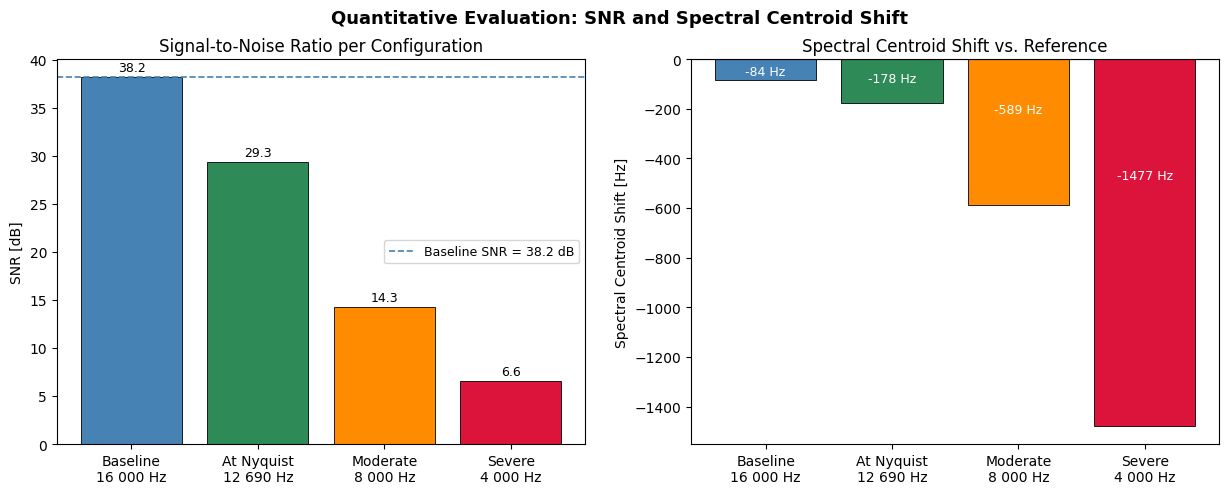

In [41]:
# Figure 1: SNR bar chart
labels_short = ['Baseline\n16 000 Hz', 'At Nyquist\n12 690 Hz',
                'Moderate\n8 000 Hz',  'Severe\n4 000 Hz']
snr_vals  = [r['snr']     for r in rows]
sc_vals   = [r['sc_diff'] for r in rows]
colors    = ['steelblue', 'seagreen', 'darkorange', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Quantitative Evaluation: SNR and Spectral Centroid Shift',
             fontsize=13, fontweight='bold')


bars = axes[0].bar(labels_short, snr_vals, color=colors, edgecolor='black', linewidth=0.6)
axes[0].axhline(y=baseline_snr, color='steelblue', linestyle='--', linewidth=1.2,
                label=f'Baseline SNR = {baseline_snr:.1f} dB')
axes[0].set_ylabel('SNR [dB]')
axes[0].set_title('Signal-to-Noise Ratio per Configuration')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, snr_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)

bars2 = axes[1].bar(labels_short, sc_vals, color=colors, edgecolor='black', linewidth=0.6)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_ylabel('Spectral Centroid Shift [Hz]')
axes[1].set_title('Spectral Centroid Shift vs. Reference')
for bar, val in zip(bars2, sc_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.3,
                 f'{val:.0f} Hz', ha='center', va='top', fontsize=9, color='white')
plt.show();

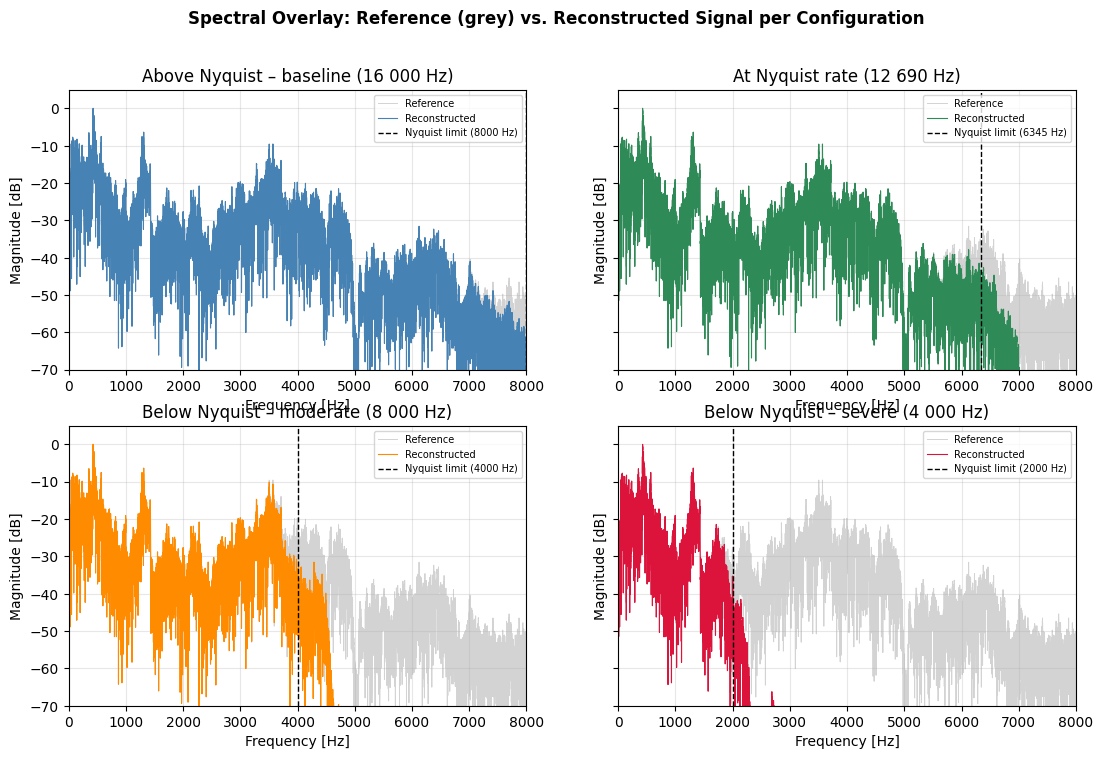

In [42]:
# Figure 2: Overlay spectra – reference vs each config
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
fig.suptitle('Spectral Overlay: Reference (grey) vs. Reconstructed Signal per Configuration',
             fontsize=12, fontweight='bold')

for ax, (label, fs_t), color in zip(axes.flat, configs.items(), colors):
    ds  = downsample(audio, fs, fs_t)
    rec = reconstruct(ds, fs_t, fs)
    n   = min(len(audio), len(rec))
    freqs = np.fft.rfftfreq(n, d=1/fs)

    spec_r  = np.abs(np.fft.rfft(audio[:n]))
    spec_c  = np.abs(np.fft.rfft(rec[:n]))
    ref_db  = 20 * np.log10(spec_r / spec_r.max() + 1e-10)
    rec_db  = 20 * np.log10(spec_c / spec_r.max() + 1e-10)  # normalize to same ref

    ax.plot(freqs, ref_db, color='lightgray', linewidth=0.7, label='Reference', zorder=1)
    ax.plot(freqs, rec_db, color=color,       linewidth=0.8, label='Reconstructed', zorder=2)
    ax.axvline(x=fs_t/2, color='black', linestyle='--', linewidth=1,
               label=f'Nyquist limit ({fs_t//2} Hz)')
    ax.set_xlim([0, 8000])
    ax.set_ylim([-70, 5])
    ax.set_title(label.replace('\n', ' '))
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Magnitude [dB]')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.show();

## Day 5 – Analysis & Communication

### Observations (3-5 sentences)
*Focus: Describe measurable results only — no explanation.*

The quantitative evaluation shows that SNR decreases monotonically from **38.16 dB** at the baseline (16 000 Hz) to **29.35 dB** at the Nyquist rate, **14.31 dB** at moderate undersampling, and **6.58 dB** at severe undersampling, yielding ΔSNR values of −8.81, −23.85, and −31.58 dB relative to the baseline.

The largest single degradation step of **15.04 dB** occurs between the Nyquist rate (12 690 Hz) and the moderate configuration (8 000 Hz).

RMSE rises from 0.00043 at baseline to 0.01616 at 4 000 Hz, an increase by a factor of approximately 38.

The spectral centroid shift SC_diff grows from −83 Hz at baseline to −1 477 Hz at severe undersampling, reflecting a progressive loss of high-frequency harmonic energy.

Performance differences are most pronounced below the Nyquist boundary: below 8 000 Hz, the reconstructed spectrum shows visible ghost components in the 0–2 000 Hz region that are absent in the reference.

### Interpretation (3-5 sentences)
*Focus: Explain what the results mean for the application.*

In the context of acoustic welfare monitoring of dromedaries at Swiss Zoos, these results imply that even theoretically sufficient sampling at the Nyquist rate (12 690 Hz) introduces an SNR drop of **8.81 dB**, reducing the reliability of harmonic ratio extraction needed for stress-state classification.

The observed variation in SNR and SC_diff affects timbral fidelity because sampling below the Nyquist boundary causes upper harmonics (H8–H11, 3 424–4 708 Hz) to alias into the cry's fundamental region, distorting the spectral fingerprint that distinguishes stress vocalisations from neutral calls.

At 4 000 Hz, the SC_diff of −1 477 Hz indicates that the perceived spectral centre has shifted by more than three times the fundamental frequency, rendering the signal unsuitable for automated welfare assessment.

This suggests that maintaining f_s well above the Nyquist rate is particularly critical for achieving the faithful spectral representation defined in the problem statement.

### Discussion and Critical Reflection (4–6 sentences)

For the defined use case, the baseline configuration (f_s = 16 000 Hz, SNR = 38.16 dB) performed well because it preserves all harmonics up to 8 000 Hz with negligible reconstruction error, which aligns with the requirement of faithful spectral representation for stress-state classification.

In contrast, both undersampled configurations (8 000 and 4 000 Hz) showed reduced performance, with SNR values of 14.31 and 6.58 dB introducing aliased ghost harmonics that would systematically mislead automated classifiers, limiting their suitability for welfare monitoring.

Sampling at the exact Nyquist rate (12 690 Hz) can be considered insufficient for this use case because the −8.81 dB degradation provides no safety margin for a system where classification errors carry animal health consequences — a rate of at least 1.5–2× the Nyquist rate (≥ 19 000 Hz) would be advisable in practice.

The implementation and evaluation assume strict band-limitation and a known ground truth at 44 100 Hz, which may be constrained under real-world conditions where broadband market noise extends beyond 6 347 Hz, potentially overstating the measured distortion.

Furthermore, the absence of an analog anti-aliasing filter in the downsampling simulation represents a worst-case scenario, as real ADC hardware would partially suppress out-of-band noise before sampling.

To improve robustness, future work should address adaptive sampling strategies and refine the evaluation by measuring welfare classification accuracy directly as a function of sampling rate.